# Eksperimen Deteksi Flaky Test: XGBoost & Random Forest

Notebook ini berisi eksperimen sesuai dengan rancangan kelompok:
1. **Model**: XGBoost dan Random Forest.
2. **Penanganan Imbalance**: `scale_pos_weight` / `class_weight`, SMOTE, Random Undersampling.
3. **Thresholding**: Pencarian threshold optimal (Max F1 atau Target Recall > 0.80).
4. **Metrik**: Precision, Recall, F1, Average Precision, Balanced Accuracy, dan Confusion Matrix.

In [11]:
%pip install pandas numpy matplotlib seaborn scikit-learn xgboost imbalanced-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score, average_precision_score, 
    balanced_accuracy_score, confusion_matrix, precision_recall_curve
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

import warnings
warnings.filterwarnings('ignore')

## 1. Load Data
Silakan sesuaikan pembacaan path dataset di bawah ini dengan dataset asli dari project (contoh: test_features.csv).

In [13]:
# df_features = pd.read_csv('../test_features.csv')
# df_results = pd.read_csv('../test_results.csv')

# Sebagai demonstrasi awal, kita generate dataset sintetis (dummy) dengan Imbalance tinggi.
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=1000, n_features=20, n_informative=10, weights=[0.95, 0.05], random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

## 2. Definisi Model dan Pipeline
Kita mendefinisikan beberapa model dan pipeline strategi penanganan imbalance, sangat disarankan menggunakan `Pipeline` dari `imblearn` agar tidak terjadi *Data Leakage* jika dikombinasikan dengan K-Fold Cross Validation.

In [14]:
ratio = sum(y_train == 0) / sum(y_train == 1)

models = {
    'XGB_ClassWeight': XGBClassifier(scale_pos_weight=ratio, random_state=42, eval_metric='logloss'),
    'XGB_SMOTE': ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('xgb', XGBClassifier(random_state=42, eval_metric='logloss'))
    ]),
    'XGB_RUS': ImbPipeline([
        ('rus', RandomUnderSampler(random_state=42)),
        ('xgb', XGBClassifier(random_state=42, eval_metric='logloss'))
    ]),
    'RF_Balanced': RandomForestClassifier(class_weight='balanced', random_state=42),
    'RF_SMOTE': ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('rf', RandomForestClassifier(random_state=42))
    ])
}

## 3. Fungsi Pencarian Threshold
Fungsi ini untuk memfasilitasi kebutuhan pencarian *decision threshold* alternatif untuk klasifikasi probabilitas yang dikeluarkan oleh model. Tidak terpaku pada `0.5`.

In [15]:
def find_optimal_threshold(y_true, y_probs, strategy='max_f1', target_recall=0.80):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_probs)
    
    if strategy == 'max_f1':
        # Hindari pembagian dengan nol
        f1_scores = (2 * precisions * recalls) / (precisions + recalls + 1e-10)
        best_idx = np.argmax(f1_scores)
        return thresholds[best_idx]
    elif strategy == 'target_recall':
        # Cari threshold tertinggi dimana recall masih memenuhi target minimal (misal >= 0.80)
        valid_idx = np.where(recalls >= target_recall)[0]
        if len(valid_idx) == 0:
            return 0.5 # fallback jika tidak ada yang memenuhi syarat
        best_idx = valid_idx[-1] 
        
        # Panjang array thresholds = len(precisions) - 1
        best_idx = min(best_idx, len(thresholds)-1)
        return thresholds[best_idx]
    
    return 0.5

## 4. Evaluasi Eksperimen
Mari kita lakukan evaluasi (pada Validation/Test set) untuk seluruh model dan metrik utama/pendukung.

In [16]:
results = []

for model_name, model in models.items():
    # 1. Training Model
    model.fit(X_train, y_train)
    
    # 2. Dapatkan Probabilitas Kelas Positif (Flaky)
    y_probs = model.predict_proba(X_test)[:, 1]
    
    # 3. Cari Threshold Optimal (Bisa diganti menjadi strategy='target_recall')
    best_thresh = find_optimal_threshold(y_test, y_probs, strategy='max_f1')
    
    # 4. Prediksi final berdasarkan Threshold
    y_pred = (y_probs >= best_thresh).astype(int)
    
    # 5. Hitung Seluruh Metrik
    avg_prec = average_precision_score(y_test, y_probs)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    
    results.append({
        'Model': model_name,
        'Best Threshold': round(best_thresh, 4),
        'Average Precision': avg_prec,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1,
        'Balanced Accuracy': bal_acc
    })

df_results = pd.DataFrame(results)
display(df_results.sort_values(by='F1 Score', ascending=False))

,Model,Best Threshold,Average Precision,Precision,Recall,F1 Score,Balanced Accuracy
1,XGB_SMOTE,0.3076,0.634122,0.615385,0.727273,0.666667,0.850409
0,XGB_ClassWeight,0.2663,0.562409,0.714286,0.454545,0.555556,0.721982
3,RF_Balanced,0.4400,0.561548,0.800000,0.363636,0.500000,0.679173
4,RF_SMOTE,0.3500,0.526861,0.428571,0.545455,0.480000,0.751563
2,XGB_RUS,0.9631,0.340706,0.333333,0.454545,0.384615,0.700818


## 5. Menampilkan Confusion Matrix (Transparansi)
Melihat performa True Positif, False Positif, dll dari model terbaik.

Menampilkan Confusion Matrix untuk: XGB_SMOTE


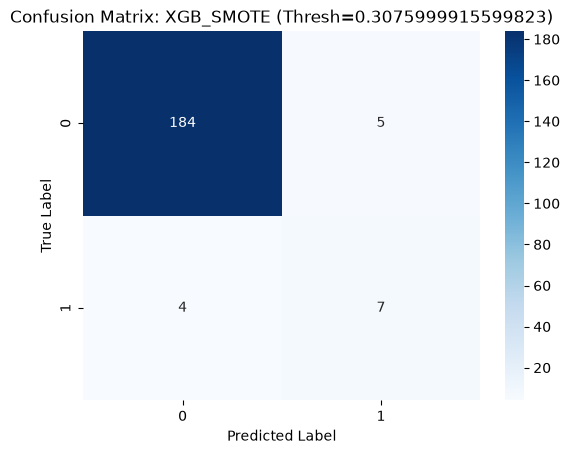

In [17]:
best_model_name = df_results.sort_values(by='F1 Score', ascending=False).iloc[0]['Model']
print(f"Menampilkan Confusion Matrix untuk: {best_model_name}")

best_model = models[best_model_name]
y_probs_best = best_model.predict_proba(X_test)[:, 1]
best_thresh_val = df_results.loc[df_results['Model'] == best_model_name, 'Best Threshold'].values[0]
y_pred_best = (y_probs_best >= best_thresh_val).astype(int)

cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix: {best_model_name} (Thresh={best_thresh_val})')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()